In [1]:
import os.path

import matplotlib.pyplot as plt
import mne.io
import pandas as pd
import yasa
from yasa import stft_power
import dataset as ds
import numpy as np
import seaborn as sns
from lspopt import spectrogram_lspopt

In [2]:

mne.set_log_level('CRITICAL')

sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette='deep',
    font='Arial',
    font_scale=1.5,
    color_codes=True,
)

plt.rc('axes', unicode_minus=False)
plt.rc('xtick', direction='out')
plt.rc('ytick', direction='out')

In [26]:
df_sessions = pd.read_excel(os.path.join(ds.path['tbl'], 'sessions.xlsx'))
animals = df_sessions['animal_id'].unique()
df_psd = pd.read_csv(os.path.join(ds.path['tbl'], 'psd.csv'))
df_psd['power_db'] = 10 * np.log10(df_psd['power']) + 120

In [42]:
df_psd_session = df_psd.groupby(['animal','session', 'freq']).agg({'power_db':'mean'})

In [43]:
df_psd_session

power_db
animal session           freq           
0628#  0628# @2024-03-14 1.0   18.097016
                         1.5   18.050131
                         2.0   16.452180
                         2.5   14.700434
                         3.0   14.709772
...                                  ...
0805#  0805# @2024-06-21 38.0   2.275745
                         38.5   2.307253
                         39.0   2.463545
                         39.5   2.471270
                         40.0   2.350530

[8216 rows x 1 columns]

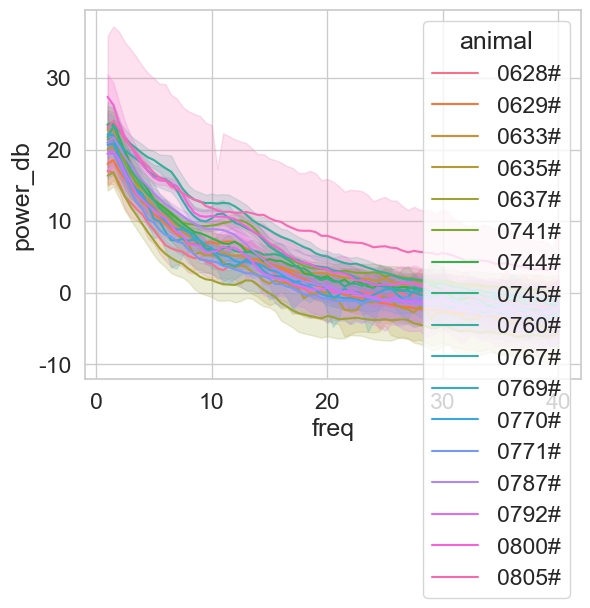

In [44]:
sns.lineplot(
    data=df_psd_session,
    x='freq',
    y='power_db',
    hue='animal',
)
plt.show()

In [46]:
df_psd.to_csv(os.path.join(ds.path['tbl'], 'psd.csv'))


In [47]:
df_psd.to_excel(os.path.join(ds.path['tbl'], 'psd2.xlsx'))

In [48]:
df_psd2 = pd.read_csv(os.path.join(ds.path['tbl'], 'psd.csv'))